In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("agriculture_yield_dataset.csv")

In [3]:
print("Rows and Columns:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

df.head(10)

Rows and Columns: (1500, 8)

Column Names:
['rainfall_mm', 'temperature_c', 'fertilizer_kg', 'irrigation_hours', 'soil_ph', 'crop_type', 'soil_type', 'yield_ton_per_hectare']


,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,crop_type,soil_type,yield_ton_per_hectare
0,588.6,18.6,242.4,6.5,6.5,Maize,Loamy,5.92
1,772.8,34.6,247.2,10.0,6.5,Maize,Sandy,6.24
2,970.9,36.3,168.4,7.3,6.4,Wheat,Sandy,4.77
3,611.7,19.0,121.7,3.7,6.0,Maize,Loamy,4.04
4,696.1,29.6,184.6,5.1,6.1,Cotton,Clay,5.17
5,831.9,28.0,190.3,2.1,6.1,Soybean,Loamy,5.50
6,1023.8,32.0,108.5,6.9,6.2,Cotton,Loamy,5.44
7,1142.4,18.4,241.9,4.1,7.3,Soybean,Sandy,5.88
8,810.4,36.4,164.8,9.9,6.5,Wheat,Loamy,6.35
9,1085.5,29.4,89.3,8.3,5.8,Cotton,Loamy,6.30


Rows: 1500
Columns: 8

In [4]:
print(df.dtypes)

print("\nMissing Values")
print(df.isnull().sum())

rainfall_mm              float64
temperature_c            float64
fertilizer_kg            float64
irrigation_hours         float64
soil_ph                  float64
crop_type                 object
soil_type                 object
yield_ton_per_hectare    float64
dtype: object

Missing Values
rainfall_mm              0
temperature_c            0
fertilizer_kg            0
irrigation_hours         0
soil_ph                  0
crop_type                0
soil_type                0
yield_ton_per_hectare    0
dtype: int64


No missing values found

In [5]:
df.describe()

print("\nHighest Mean Feature:",
      df.select_dtypes(include=np.number)
      .mean()
      .idxmax())

print("\nHighest Standard Deviation Feature:",
      df.select_dtypes(include=np.number)
      .std()
      .idxmax())


Highest Mean Feature: rainfall_mm

Highest Standard Deviation Feature: rainfall_mm


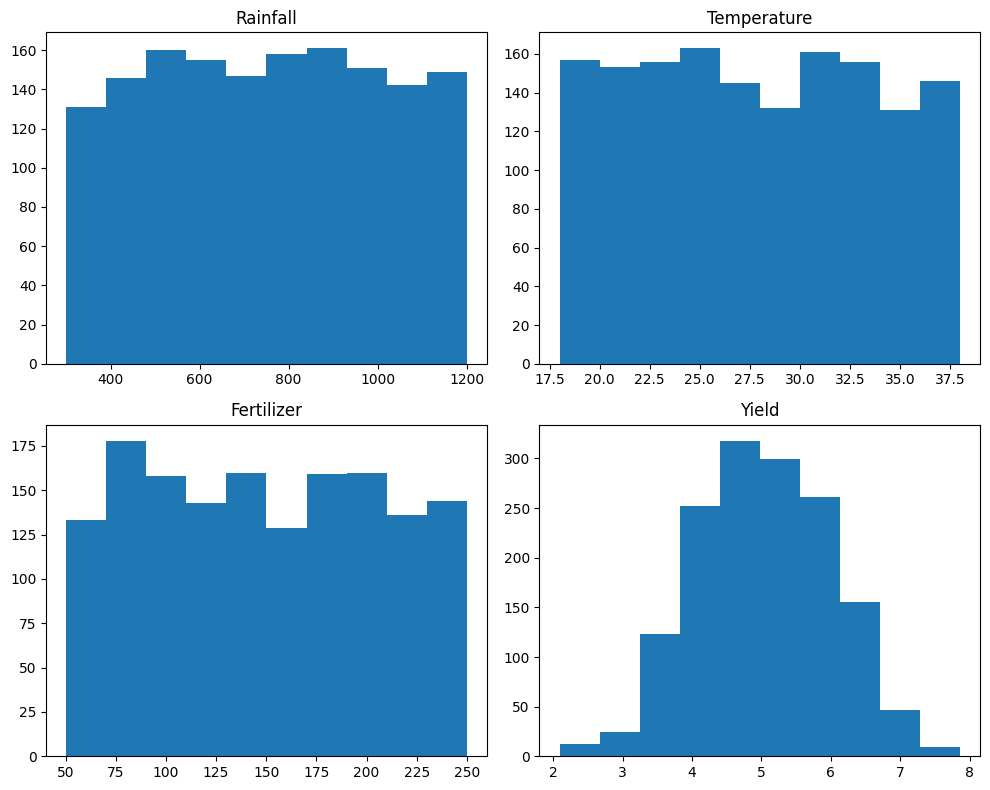

In [6]:
fig, ax = plt.subplots(2,2, figsize=(10,8))

ax[0,0].hist(df["rainfall_mm"])
ax[0,0].set_title("Rainfall")

ax[0,1].hist(df["temperature_c"])
ax[0,1].set_title("Temperature")

ax[1,0].hist(df["fertilizer_kg"])
ax[1,0].set_title("Fertilizer")

ax[1,1].hist(df["yield_ton_per_hectare"])
ax[1,1].set_title("Yield")

plt.tight_layout()
plt.show()

Rainfall values are spread across a wide range.
Temperature values are fairly balanced.
Yield distribution is approximately normal

crop_type
Cotton     311
Soybean    306
Wheat      303
Rice       293
Maize      287
Name: count, dtype: int64


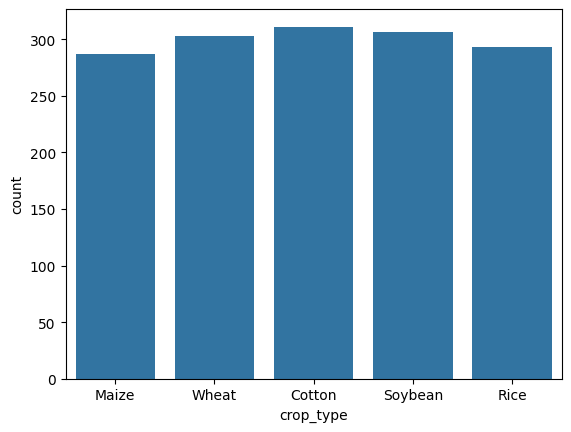

Most Frequent Crop: Cotton


In [7]:
print(df["crop_type"].value_counts())

sns.countplot(x="crop_type", data=df)
plt.show()

print("Most Frequent Crop:",
      df["crop_type"].value_counts().idxmax())

cotton

soil_type
Clay     534
Sandy    492
Loamy    474
Name: count, dtype: int64


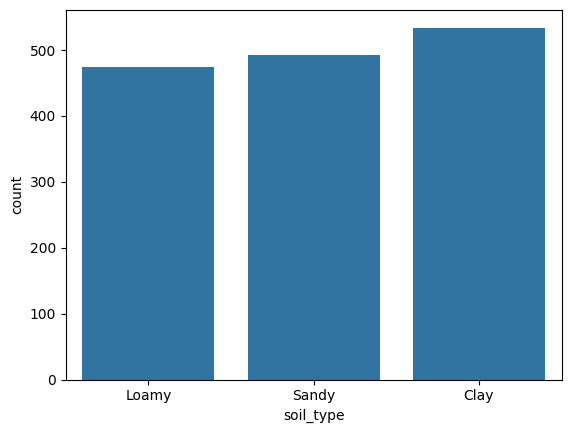

Most Common Soil: Clay


In [8]:
print(df["soil_type"].value_counts())

sns.countplot(x="soil_type", data=df)
plt.show()

print("Most Common Soil:",
      df["soil_type"].value_counts().idxmax())

clay

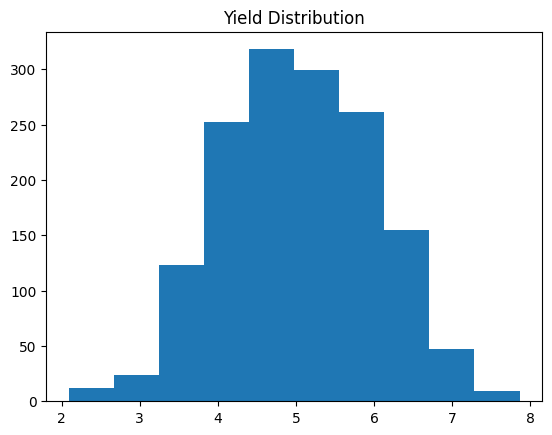

In [9]:
plt.hist(df["yield_ton_per_hectare"])
plt.title("Yield Distribution")
plt.show()

Distribution is approximately normal.
Most values are around the center.
No major outliers are visible

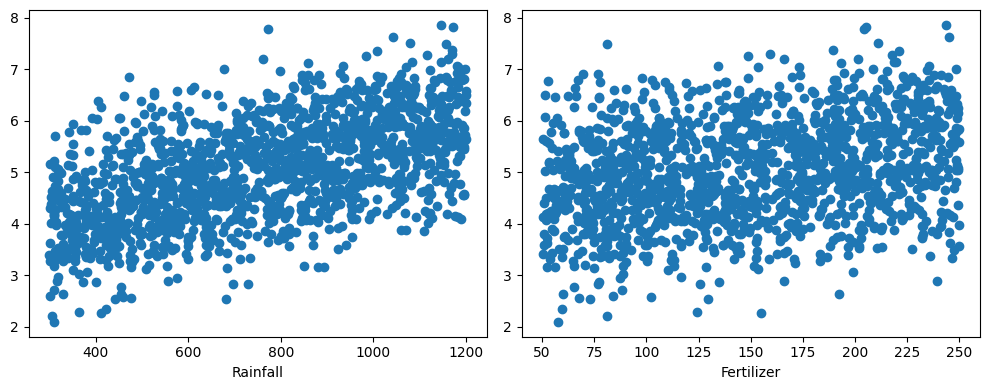

In [10]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.scatter(df["rainfall_mm"],
            df["yield_ton_per_hectare"])
plt.xlabel("Rainfall")

plt.subplot(1,2,2)
plt.scatter(df["fertilizer_kg"],
            df["yield_ton_per_hectare"])
plt.xlabel("Fertilizer")

plt.tight_layout()
plt.show()

Rainfall appears to have a stronger relationship with yield than fertilizer.

                       rainfall_mm  temperature_c  fertilizer_kg  \
rainfall_mm               1.000000       0.026721       0.002558   
temperature_c             0.026721       1.000000       0.037468   
fertilizer_kg             0.002558       0.037468       1.000000   
irrigation_hours          0.010877       0.007114      -0.010497   
soil_ph                   0.006916       0.001513       0.010001   
yield_ton_per_hectare     0.553704      -0.022559       0.278043   

                       irrigation_hours   soil_ph  yield_ton_per_hectare  
rainfall_mm                    0.010877  0.006916               0.553704  
temperature_c                  0.007114  0.001513              -0.022559  
fertilizer_kg                 -0.010497  0.010001               0.278043  
irrigation_hours               1.000000  0.009307               0.542664  
soil_ph                        0.009307  1.000000               0.024412  
yield_ton_per_hectare          0.542664  0.024412               1.000000 

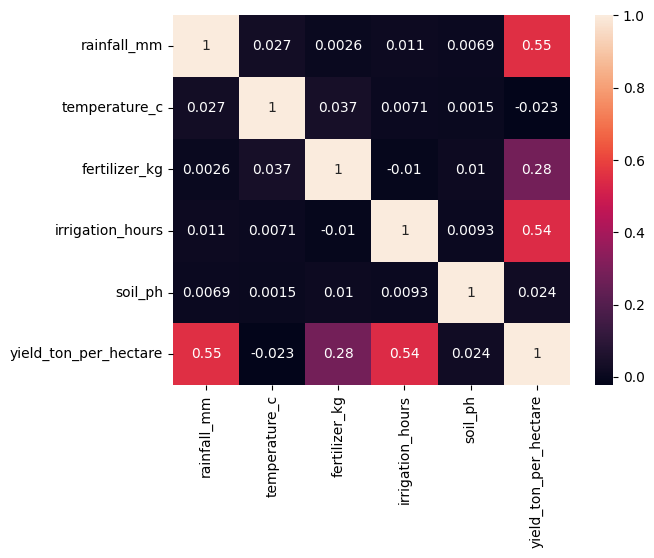

yield_ton_per_hectare    1.000000
rainfall_mm              0.553704
irrigation_hours         0.542664
fertilizer_kg            0.278043
soil_ph                  0.024412
temperature_c           -0.022559
Name: yield_ton_per_hectare, dtype: float64


In [11]:
corr = df.select_dtypes(include=np.number).corr()

print(corr)

sns.heatmap(corr, annot=True)
plt.show()

print(corr["yield_ton_per_hectare"]
      .sort_values(ascending=False))

rainfall_mm

irrigation_hours

fertilizer_kg

In [12]:
crop_avg = df.groupby("crop_type")[
    "yield_ton_per_hectare"
].mean()

soil_avg = df.groupby("soil_type")[
    "yield_ton_per_hectare"
].mean()

print(crop_avg)

print("\n")
print(soil_avg)

crop_type
Cotton     4.607299
Maize      4.897143
Rice       5.494744
Soybean    5.173431
Wheat      4.989472
Name: yield_ton_per_hectare, dtype: float64


soil_type
Clay     5.134326
Loamy    5.366519
Sandy    4.588882
Name: yield_ton_per_hectare, dtype: float64


Highest Yield Crop: Rice
Highest Yield Soil: Loamy

In [13]:
print(df.select_dtypes(include="object").columns)

df1 = pd.get_dummies(df, drop_first=True)

df1.head()

Index(['crop_type', 'soil_type'], dtype='object')


,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,yield_ton_per_hectare,crop_type_Maize,crop_type_Rice,crop_type_Soybean,crop_type_Wheat,soil_type_Loamy,soil_type_Sandy
0,588.6,18.6,242.4,6.5,6.5,5.92,True,False,False,False,True,False
1,772.8,34.6,247.2,10.0,6.5,6.24,True,False,False,False,False,True
2,970.9,36.3,168.4,7.3,6.4,4.77,False,False,False,True,False,True
3,611.7,19.0,121.7,3.7,6.0,4.04,True,False,False,False,True,False
4,696.1,29.6,184.6,5.1,6.1,5.17,False,False,False,False,False,False


crop_type

soil_type

In [14]:
X = df1.drop("yield_ton_per_hectare", axis=1)

y = df1["yield_ton_per_hectare"]

print("Target Variable: yield_ton_per_hectare")

Target Variable: yield_ton_per_hectare


yield_ton_per_hectare

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1200, 11)
(300, 11)
(1200,)
(300,)


(1200, 11)
(300, 11)
(1200,)
(300,)

In [16]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

print("Intercept:")
print(model.intercept_)

coef = pd.Series(
    model.coef_,
    index=X.columns
)

print("\nCoefficients")
print(coef.sort_values(ascending=False))

Intercept:
1.587132027736121

Coefficients
crop_type_Rice       0.863993
crop_type_Soybean    0.481719
crop_type_Wheat      0.348474
soil_type_Loamy      0.302974
crop_type_Maize      0.238931
irrigation_hours     0.198327
fertilizer_kg        0.004978
soil_ph              0.004901
rainfall_mm          0.002035
temperature_c       -0.009175
soil_type_Sandy     -0.490933
dtype: float64


Intercept = 1.587132027736121
Highest Positive Coefficient Feature = crop_type_Rice (0.863993)